In [1]:
# Cài đặt model
#pip install statsmodels
#pip install openpyxl
#!pip install seaborn
#!pip install networkx

## 1. Khởi tạo môi trường & import thư viện

In [69]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import jarque_bera, shapiro
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.stattools import acf, pacf
import statsmodels.api as sm

plt.style.use("ggplot")
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 160)

def hline(text=""):
    print("-" * 80)
    if text:
        print("📌 KẾT LUẬN / DIỄN GIẢI:")
        print(text)
    print("-" * 80)

## 2. Nạp dữ liệu gốc & Tiền xử lý dữ liệu ( Xoá dòng trùng )

In [70]:
file_path = "FINAL DATASET.xlsx"
df_raw = pd.read_excel(file_path)

df = df_raw.copy()
df.columns = [c.lower() for c in df.columns]

df["time"] = pd.to_datetime(df["time"])

# Lọc từ ngày 2021-03-24
df = df[df["time"] >= "2021-03-24"].copy()

# ✨ Loại bỏ toàn bộ dữ liệu của mã ROS
df = df[df["symbol"] != "ROS"].copy()

before = df.shape[0]
df = df.drop_duplicates(subset=["time", "symbol"], keep="first")
after = df.shape[0]

print(df.head())
print("Kích thước sau lọc ngày & xoá trùng:", df.shape)
print("Số dòng trùng đã loại:", before - after)

print("\nSố mã cổ phiếu:", df["symbol"].nunique())
print("Khoảng thời gian:", df["time"].min(), "→", df["time"].max())

hline(
    "- Đã giới hạn dữ liệu kể từ ngày 24/03/2021 để tránh các phiên có dữ liệu thiếu cho một số mã.\n"
    "- Đã loại bỏ mã chứng khoán ROS vì bị huỷ niêm yết và thiếu thời gian quá nhiều.\n"
    "- Đã loại bỏ các dòng trùng lặp theo (time, symbol), đảm bảo mỗi mã chỉ có một quan sát duy nhất mỗi ngày.\n"
    "- Dataset sau xử lý có cấu trúc sạch, phù hợp để pivot sang dạng wide và phân tích sâu hơn."
)

        time   open  close   volume symbol industry     order  usdvnd  usdreturn
0 2021-03-24  12.16  12.18  9941600    ACB    Banks  0.035794   23.08   0.000173
2 2021-03-25  12.19  12.02  8322000    ACB    Banks -0.065665  23.084   0.000000
4 2021-03-26  12.01  12.18  7931700    ACB    Banks  0.024183  23.084  -0.000607
6 2021-03-29  12.34  12.38  6981300    ACB    Banks -0.005518   23.07   0.000000
8 2021-03-30  12.42  12.49  8053200    ACB    Banks -0.152632   23.07   0.000173
Kích thước sau lọc ngày & xoá trùng: (47475, 9)
Số dòng trùng đã loại: 11224

Số mã cổ phiếu: 41
Khoảng thời gian: 2021-03-24 00:00:00 → 2025-11-10 00:00:00
--------------------------------------------------------------------------------
📌 KẾT LUẬN / DIỄN GIẢI:
- Đã giới hạn dữ liệu kể từ ngày 24/03/2021 để tránh các phiên có dữ liệu thiếu cho một số mã.
- Đã loại bỏ mã chứng khoán ROS vì bị huỷ niêm yết và thiếu thời gian quá nhiều.
- Đã loại bỏ các dòng trùng lặp theo (time, symbol), đảm bảo mỗi mã chỉ có m

# 3. Top 20 cổ phiếu có Khối lượng cao nhất

In [71]:
# Tính log_returns
prices = df.pivot(index="time", columns="symbol", values="close")
log_returns = np.log(prices).diff()
log_returns = log_returns.dropna(how="all")

In [72]:
import numpy as np
import pandas as pd
from statsmodels.tsa.api import VAR
from statsmodels.tsa.stattools import adfuller

# Cột sử dụng
DATE_COL    = "time"
SYMBOL_COL  = "symbol"
VOLUME_COL  = "volume"
USDRET_COL  = "usdreturn"
ORDER_COL   = "order"

TOP_N_STOCKS = 20
EXCLUDE = ["VNINDEX", "VN30", "VN30INDEX", "ROS"]

# Lọc bỏ index & ROS trước khi xếp hạng thanh khoản
df_liq = df[~df[SYMBOL_COL].isin(EXCLUDE)].copy()

liq_stats = (
    df_liq.groupby(SYMBOL_COL)[VOLUME_COL]
          .mean()
          .sort_values(ascending=False)
)

top_symbols = liq_stats.head(TOP_N_STOCKS).index.tolist()

print(f"TOP {TOP_N_STOCKS} mã theo thanh khoản (đã loại VNINDEX/VN30/ROS):")
print(top_symbols)
print("Số mã được chọn:", len(top_symbols))

TOP 20 mã theo thanh khoản (đã loại VNINDEX/VN30/ROS):
['SHB', 'HPG', 'SSI', 'VPB', 'STB', 'MBB', 'NVL', 'TCB', 'TPB', 'PDR', 'TCH', 'CTG', 'ACB', 'HDB', 'LPB', 'VRE', 'VHM', 'EIB', 'MWG', 'VIB']
Số mã được chọn: 20


In [73]:
# Tính log_vol_return

df_vol = df[df["volume"] > 0].copy()          
df_vol["log_volume"] = np.log(df_vol["volume"])

# Sai phân log-volume theo từng mã 
df_vol = df_vol.sort_values(["symbol", "time"])
df_vol["log_vol_return"] = df_vol.groupby("symbol")["log_volume"].diff()

In [74]:
# Lọc log_returns chỉ giữ 20 mã đã chọn
ret20 = log_returns[top_symbols].copy()

# Giới hạn cùng thời gian với df nếu muốn chắc chắn
ret20 = ret20[ret20.index >= pd.to_datetime("2021-03-24")]

print("Shape ret20 trước dropna:", ret20.shape)

# Bỏ những ngày thiếu bất kỳ mã nào
ret20 = ret20.dropna(how="any")

print("Shape ret20 sau dropna:", ret20.shape)
print("Các mã trong ret20:", list(ret20.columns))

Shape ret20 trước dropna: (1157, 20)
Shape ret20 sau dropna: (1153, 20)
Các mã trong ret20: ['SHB', 'HPG', 'SSI', 'VPB', 'STB', 'MBB', 'NVL', 'TCB', 'TPB', 'PDR', 'TCH', 'CTG', 'ACB', 'HDB', 'LPB', 'VRE', 'VHM', 'EIB', 'MWG', 'VIB']


In [75]:
usd_series = (
    df.groupby(DATE_COL)[USDRET_COL]
      .first()
      .reindex(ret20.index)
)

order_series = (
    df[df[SYMBOL_COL].isin(top_symbols)]
      .groupby(DATE_COL)[ORDER_COL]
      .mean()
      .reindex(ret20.index)
)

vol_series = (
    df_vol[df_vol[SYMBOL_COL].isin(top_symbols)]
      .groupby(DATE_COL)["log_vol_return"]
      .mean()
      .reindex(ret20.index)
)

# Gộp thành dataset cuối cùng cho ADF / VAR / Granger
data_for_var = ret20.copy()
data_for_var["usdreturn"] = usd_series
data_for_var["order_avg"] = order_series
data_for_var["volavg"]    = vol_series

print("Shape trước dropna (full dataset):", data_for_var.shape)
print("NA theo cột:")
print(data_for_var.isna().sum())

# Bỏ mọi dòng còn thiếu bất kỳ biến nào
data_for_var = data_for_var.dropna(how="any")

print("Final data_for_var shape:", data_for_var.shape)
print("Các biến trong data_for_var:", list(data_for_var.columns))

Shape trước dropna (full dataset): (1153, 23)
NA theo cột:
symbol
SHB          0
HPG          0
SSI          0
VPB          0
STB          0
MBB          0
NVL          0
TCB          0
TPB          0
PDR          0
TCH          0
CTG          0
ACB          0
HDB          0
LPB          0
VRE          0
VHM          0
EIB          0
MWG          0
VIB          0
usdreturn    0
order_avg    0
volavg       0
dtype: int64
Final data_for_var shape: (1153, 23)
Các biến trong data_for_var: ['SHB', 'HPG', 'SSI', 'VPB', 'STB', 'MBB', 'NVL', 'TCB', 'TPB', 'PDR', 'TCH', 'CTG', 'ACB', 'HDB', 'LPB', 'VRE', 'VHM', 'EIB', 'MWG', 'VIB', 'usdreturn', 'order_avg', 'volavg']


In [78]:
def adf_test(series, name=""):
    s = series.dropna()
    stat, pval = adfuller(s)[0:2]
    print(f"ADF – {name:12s}: stat = {stat:8.3f}, p-value = {pval:8.4f}")

print("ADF test cho tất cả biến trong data_for_var")
for col in data_for_var.columns:
    adf_test(data_for_var[col], name=col)

ADF test cho tất cả biến trong data_for_var
ADF – SHB         : stat =  -30.163, p-value =   0.0000
ADF – HPG         : stat =  -31.820, p-value =   0.0000
ADF – SSI         : stat =  -18.690, p-value =   0.0000
ADF – VPB         : stat =   -6.478, p-value =   0.0000
ADF – STB         : stat =  -26.065, p-value =   0.0000
ADF – MBB         : stat =  -24.733, p-value =   0.0000
ADF – NVL         : stat =   -7.882, p-value =   0.0000
ADF – TCB         : stat =  -31.703, p-value =   0.0000
ADF – TPB         : stat =  -11.006, p-value =   0.0000
ADF – PDR         : stat =  -12.247, p-value =   0.0000
ADF – TCH         : stat =  -31.932, p-value =   0.0000
ADF – CTG         : stat =  -25.554, p-value =   0.0000
ADF – ACB         : stat =  -20.830, p-value =   0.0000
ADF – HDB         : stat =  -34.349, p-value =   0.0000
ADF – LPB         : stat =  -24.371, p-value =   0.0000
ADF – VRE         : stat =  -25.176, p-value =   0.0000
ADF – VHM         : stat =  -30.067, p-value =   0.0000
ADF 

In [79]:
from statsmodels.tsa.api import VAR

data_for_var_var = data_for_var.copy()
data_for_var_var.index = pd.RangeIndex(start=0, stop=len(data_for_var_var), step=1)

model = VAR(data_for_var_var)

lag_order_res = model.select_order(maxlags=5)
print(lag_order_res.summary())

p_opt = 1   
print("Lag VAR sử dụng cho Granger:", p_opt)

var_res = model.fit(p_opt)
print(var_res.summary())

 VAR Order Selection (* highlights the minimums) 
      AIC         BIC         FPE         HQIC   
-------------------------------------------------
0      -182.7     -182.6*   4.364e-80     -182.7*
1     -183.2*      -180.8  2.758e-80*      -182.3
2      -183.0      -178.2   3.360e-80      -181.2
3      -182.7      -175.7   4.327e-80      -180.1
4      -182.4      -173.0   5.878e-80      -178.9
5      -182.2      -170.4   7.938e-80      -177.7
-------------------------------------------------
Lag VAR sử dụng cho Granger: 1
  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Mon, 24, Nov, 2025
Time:                     17:09:39
--------------------------------------------------------------------
No. of Equations:         23.0000    BIC:                   -180.732
Nobs:                     1152.00    HQIC:                  -182.238
Log likelihood:           68450.8    FPE:                2.87456e-80
AIC:              

In [80]:
# ĐÁNH GIÁ MÔ HÌNH VAR DÙNG CHO CGCI
# Kiểm tra residual có phải "white noise" không (Portmanteau / Ljung-Box)

nlags_test = 10  # có thể chỉnh 10–15, nhưng phải > p_opt
white_test = var_res.test_whiteness(nlags=nlags_test, signif=0.05)

print("=== Residual Whiteness Test (Portmanteau) ===")
print(white_test.summary())
print("\nGiải thích nhanh:")
print(f"- H0: residual là white noise (không còn tự tương quan).")
print(f"- p-value = {white_test.pvalue:.4f}")
print("  Nếu p-value > 0.05 → KHÔNG bác bỏ H0 → mô hình OK về mặt tự tương quan.\n")

# Kiểm tra phân phối chuẩn của residual (Jarque–Bera kiểu omnibus)

norm_test = var_res.test_normality(signif=0.05)

print("=== Residual Normality Test (Jarque–Bera omnibus) ===")
print(norm_test.summary())
print("\nGiải thích nhanh:")
print(f"- H0: residual tuân theo phân phối chuẩn.")
print(f"- p-value = {norm_test.pvalue:.4f}")
print("  Nếu p-value > 0.05 → KHÔNG bác bỏ H0 → giả định normality tạm chấp nhận.")

=== Residual Whiteness Test (Portmanteau) ===
Portmanteau-test for residual autocorrelation. H_0: residual autocorrelation up to lag 10 is zero. Conclusion: reject H_0 at 5% significance level.
Test statistic Critical value p-value  df 
------------------------------------------
         5685.          4923.   0.000 4761
------------------------------------------

Giải thích nhanh:
- H0: residual là white noise (không còn tự tương quan).
- p-value = 0.0000
  Nếu p-value > 0.05 → KHÔNG bác bỏ H0 → mô hình OK về mặt tự tương quan.

=== Residual Normality Test (Jarque–Bera omnibus) ===
normality (skew and kurtosis) test. H_0: data generated by normally-distributed process. Conclusion: reject H_0 at 5% significance level.
Test statistic Critical value p-value df
----------------------------------------
     2.350e+07          62.83   0.000 46
----------------------------------------

Giải thích nhanh:
- H0: residual tuân theo phân phối chuẩn.
- p-value = 0.0000
  Nếu p-value > 0.05 → KHÔNG

In [81]:
from statsmodels.stats.diagnostic import het_arch

# Kiểm tra ARCH effects (phương sai thay đổi theo thời gian) cho từng series

arch_results = {}

for col in data_for_var_var.columns:
    resid_series = var_res.resid[col].dropna()
    arch_stat, arch_pvalue, _, _ = het_arch(resid_series, nlags=5)
    arch_results[col] = {
        "ARCH_stat": arch_stat,
        "ARCH_pvalue": arch_pvalue
    }

arch_table = (
    pd.DataFrame(arch_results)
      .T
      .sort_values("ARCH_pvalue")
)

arch_table["H0_no_ARCH_rejected"] = arch_table["ARCH_pvalue"] < 0.05

print("=== ARCH test cho từng biến trong VAR (nlags = 5) ===")
print(arch_table)

print("\nGiải thích nhanh:")
print("- H0: không có hiệu ứng ARCH (phương sai không phụ thuộc vào độ trễ).")
print("- Nếu ARCH_pvalue < 0.05 → bác bỏ H0 → có dấu hiệu heteroskedasticity (ARCH effect).")

=== ARCH test cho từng biến trong VAR (nlags = 5) ===
            ARCH_stat   ARCH_pvalue  H0_no_ARCH_rejected
volavg     177.348893  1.970445e-36                 True
ACB        164.281836  1.209935e-33                 True
EIB        144.672002  1.816535e-29                 True
SSI        117.148961  1.260161e-23                 True
LPB        115.937407  2.274336e-23                 True
NVL        115.554692  2.740584e-23                 True
TCH        115.159184  3.323008e-23                 True
STB        108.613978  8.041945e-22                 True
SHB        103.041808  1.206914e-20                 True
MWG        102.898079  1.294181e-20                 True
HPG        102.708751  1.418830e-20                 True
VIB        100.205570  4.783322e-20                 True
CTG         98.623827  1.030486e-19                 True
VPB         90.094030  6.420551e-18                 True
TCB         83.999709  1.219963e-16                 True
VRE         80.156955  7.780713e-1

In [82]:
eval_summary = {
    "whiteness_pvalue": white_test.pvalue,
    "normality_pvalue": norm_test.pvalue,
    "n_series_with_ARCH": int((arch_table["H0_no_ARCH_rejected"]).sum()),
    "total_series": arch_table.shape[0],
    "lag_used_for_VAR": p_opt
}

print("=== TÓM TẮT ĐÁNH GIÁ MÔ HÌNH VAR ===")
for k, v in eval_summary.items():
    print(f"{k}: {v}")

=== TÓM TẮT ĐÁNH GIÁ MÔ HÌNH VAR ===
whiteness_pvalue: 2.3006470170289656e-19
normality_pvalue: 0.0
n_series_with_ARCH: 22
total_series: 23
lag_used_for_VAR: 1


In [84]:
alpha = 0.05

stocks = [c for c in data_for_var_var.columns if c not in ["usdreturn", "order_avg", "volavg"]]

adj_matrix  = pd.DataFrame(0, index=stocks, columns=stocks, dtype=int)
pval_matrix = pd.DataFrame(np.nan, index=stocks, columns=stocks)

for cause in stocks:
    for effect in stocks:
        if cause == effect:
            continue

        test_res = var_res.test_causality(
            caused=effect,
            causing=[cause],
            kind="f"
        )
        pval = test_res.pvalue

        pval_matrix.loc[cause, effect] = pval
        if pval < alpha:
            adj_matrix.loc[cause, effect] = 1

num_sig = int(adj_matrix.values.sum())
print("Số quan hệ Granger có ý nghĩa (p <", alpha, "):", num_sig)

# === HIỆN MA TRẬN Ở DƯỚI ===
print("\n=== Adjacency Matrix (1 = quan hệ có ý nghĩa) ===")
print(adj_matrix)

Số quan hệ Granger có ý nghĩa (p < 0.05 ): 55

=== Adjacency Matrix (1 = quan hệ có ý nghĩa) ===
     SHB  HPG  SSI  VPB  STB  MBB  NVL  TCB  TPB  PDR  TCH  CTG  ACB  HDB  LPB  VRE  VHM  EIB  MWG  VIB
SHB    0    0    0    0    0    0    0    0    0    0    0    0    0    0    0    0    1    0    0    0
HPG    0    0    0    0    0    0    0    0    0    0    0    0    0    0    0    0    0    0    0    0
SSI    0    0    0    1    0    1    0    0    1    1    1    1    0    0    0    1    0    0    0    0
VPB    0    0    0    0    0    0    0    0    0    0    0    0    0    0    1    0    0    0    0    0
STB    0    0    0    1    0    1    0    0    0    1    0    0    0    0    0    1    0    0    1    0
MBB    0    0    0    1    0    0    0    0    0    1    0    0    1    0    0    0    0    1    1    0
NVL    0    0    0    0    0    0    0    1    0    1    0    0    1    0    0    0    1    0    0    0
TCB    0    0    0    0    0    0    0    0    0    0    0    0    0   

In [85]:
# out_degree: số cạnh i -> j (hàng)
out_deg = adj_matrix.sum(axis=1)

# in_degree: số cạnh k -> i (cột)
in_deg  = adj_matrix.sum(axis=0)

deg_df = pd.DataFrame({
    "out_degree": out_deg,
    "in_degree": in_deg
})
deg_df["net_degree"] = deg_df["out_degree"] - deg_df["in_degree"]

print("Bảng độ trung tâm (degree) của từng cổ phiếu:")
print(deg_df.sort_values("out_degree", ascending=False))

Bảng độ trung tâm (degree) của từng cổ phiếu:
     out_degree  in_degree  net_degree
PDR          10          5           5
SSI           7          3           4
TCH           6          3           3
STB           5          2           3
MBB           5          4           1
CTG           4          2           2
NVL           4          2           2
EIB           3          1           2
MWG           2          3          -1
VRE           2          5          -3
SHB           1          1           0
VPB           1          5          -4
VHM           1          3          -2
HDB           1          0           1
LPB           1          3          -2
ACB           1          3          -2
VIB           1          2          -1
HPG           0          4          -4
TPB           0          2          -2
TCB           0          2          -2


In [86]:
transmitters = deg_df[deg_df["net_degree"] > 0].index.tolist()
neutrals     = deg_df[deg_df["net_degree"] == 0].index.tolist()
receivers    = deg_df[deg_df["net_degree"] < 0].index.tolist()

print("Transmitters (shock emitters):", transmitters)
print("Neutrals:", neutrals)
print("Receivers (shock absorbers):", receivers)

Transmitters (shock emitters): ['SSI', 'STB', 'MBB', 'NVL', 'PDR', 'TCH', 'CTG', 'HDB', 'EIB']
Neutrals: ['SHB']
Receivers (shock absorbers): ['HPG', 'VPB', 'TCB', 'TPB', 'ACB', 'LPB', 'VRE', 'VHM', 'MWG', 'VIB']


In [87]:
# --- TOP 5 TRANSMITTERS & RECEIVERS ---

top5_transmitters = deg_df.sort_values("net_degree", ascending=False).head(5)

top5_receivers = deg_df.sort_values("net_degree", ascending=True).head(5)

print("===== TOP 5 TRANSMITTERS (Shock Emitters) =====")
print(top5_transmitters)

print("\n===== TOP 5 RECEIVERS (Shock Absorbers) =====")
print(top5_receivers)


===== TOP 5 TRANSMITTERS (Shock Emitters) =====
     out_degree  in_degree  net_degree
PDR          10          5           5
SSI           7          3           4
STB           5          2           3
TCH           6          3           3
CTG           4          2           2

===== TOP 5 RECEIVERS (Shock Absorbers) =====
     out_degree  in_degree  net_degree
HPG           0          4          -4
VPB           1          5          -4
VRE           2          5          -3
TCB           0          2          -2
LPB           1          3          -2


Số node: 20
Số cạnh: 55


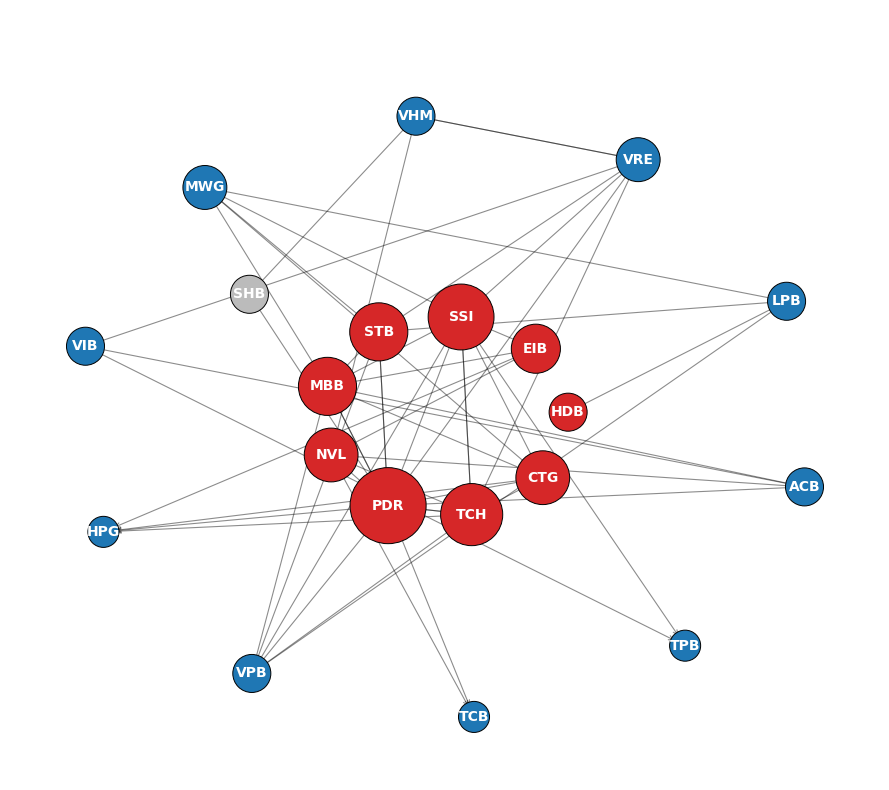

In [88]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np

G = nx.DiGraph()

# Thêm node
for n in adj_matrix.index:
    G.add_node(n)

# Thêm cạnh theo CGCI
for i in adj_matrix.index:
    for j in adj_matrix.columns:
        if adj_matrix.loc[i, j] == 1:
            G.add_edge(i, j)

print("Số node:", G.number_of_nodes())
print("Số cạnh:", G.number_of_edges())

# Node size theo out_degree
sizes = [500 + 250 * deg_df.loc[n, "out_degree"] for n in G.nodes()]

# Node color theo role
colors = []
for n in G.nodes():
    if n in transmitters:
        colors.append("#d62728")  # đỏ
    elif n in receivers:
        colors.append("#1f77b4")  # xanh
    else:
        colors.append("#bbbbbb")  # xám

shells = []
if transmitters:
    shells.append(transmitters)
if neutrals:
    shells.append(neutrals)
if receivers:
    shells.append(receivers)

pos = nx.shell_layout(G, nlist=shells)

angle = np.pi / 8
rot_pos = {}
for k, (x, y) in pos.items():
    rot_pos[k] = (x*np.cos(angle) - y*np.sin(angle),
                  x*np.sin(angle) + y*np.cos(angle))

plt.figure(figsize=(9, 8))

nx.draw_networkx_edges(
    G, rot_pos,
    arrowstyle="->",
    arrowsize=8,
    width=0.8,
    alpha=0.45
)

nx.draw_networkx_nodes(
    G, rot_pos,
    node_size=sizes,
    node_color=colors,
    edgecolors="black",
    linewidths=0.7
)

nx.draw_networkx_labels(
    G, rot_pos,
    font_size=10,
    font_weight="bold",
    font_color="white"
)

plt.title("CGCI Network – Top 20 VN30 Stocks\nShell layout: inner=transmitters, outer=receivers",
          fontsize=13, color="white")

plt.axis("off")
plt.tight_layout()
plt.show()

Số node: 20
Số cạnh: 55


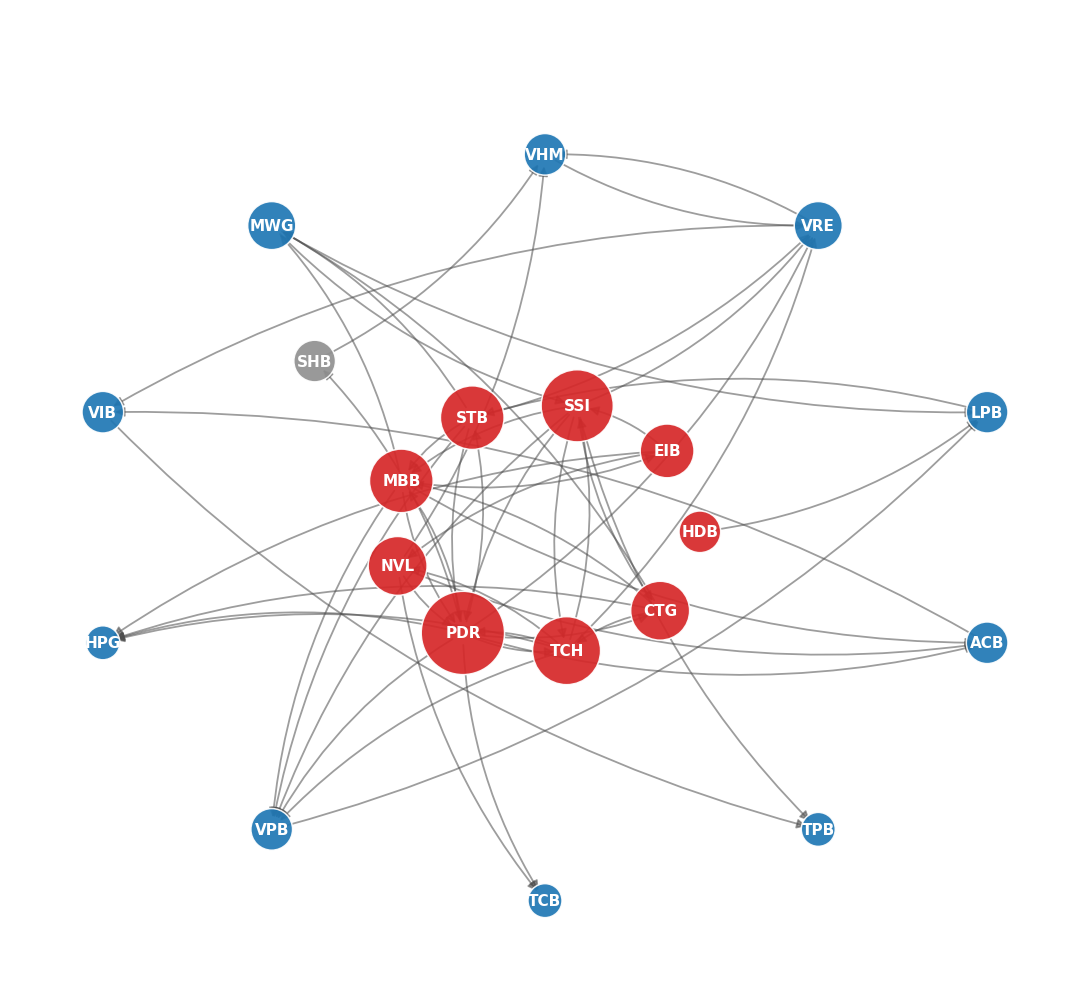

Ảnh đã lưu: network_compare1.png & network_compare1.svg


In [89]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np

G = nx.DiGraph()

# Thêm node
for n in adj_matrix.index:
    G.add_node(n)

# Thêm cạnh theo CGCI
for i in adj_matrix.index:
    for j in adj_matrix.columns:
        if adj_matrix.loc[i, j] == 1:
            G.add_edge(i, j)

print("Số node:", G.number_of_nodes())
print("Số cạnh:", G.number_of_edges())

sizes = [600 + 300 * deg_df.loc[n, "out_degree"] for n in G.nodes()]

# ===== Node color theo role =====
colors = []
for n in G.nodes():
    if n in transmitters:
        colors.append("#d62728")   
    elif n in receivers:
        colors.append("#1f77b4")   
    else:
        colors.append("#909090")   

shells = []
if transmitters:
    shells.append(transmitters)
if neutrals:
    shells.append(neutrals)
if receivers:
    shells.append(receivers)

pos = nx.shell_layout(G, nlist=shells)

angle = np.pi / 10
rot_pos = {
    k: (x*np.cos(angle) - y*np.sin(angle),
        x*np.sin(angle) + y*np.cos(angle))
    for k, (x, y) in pos.items()
}

plt.figure(figsize=(11, 10))
plt.style.use("seaborn-v0_8")

nx.draw_networkx_edges(
    G, rot_pos,
    arrowstyle="-|>",
    arrowsize=14,
    width=1.3,
    alpha=0.55,
    edge_color="#4d4d4d",
    connectionstyle="arc3,rad=0.14"  
)

# ===== Vẽ node =====
nx.draw_networkx_nodes(
    G, rot_pos,
    node_size=sizes,
    node_color=colors,
    edgecolors="white",   
    linewidths=1.1,
    alpha=0.92
)

nx.draw_networkx_labels(
    G, rot_pos,
    font_size=11,
    font_weight="bold",
    font_color="white"
)

plt.title(
    "CGCI Network – Top 20 VN30 Stocks\nShell layout: inner = transmitters, outer = receivers",
    fontsize=15,
    fontweight="bold",
    color="white",
    pad=20
)

plt.axis("off")
plt.tight_layout()

plt.savefig("network_compare1.png", dpi=600, bbox_inches="tight")           # PNG HD
plt.savefig("network_compare1.svg", format="svg", bbox_inches="tight")     # Vector

plt.show()

print("Ảnh đã lưu: network_compare1.png & network_compare1.svg")

# 4. Top 20 cổ phiếu có Biến động cao nhất

In [90]:
prices = df.pivot(index="time", columns="symbol", values="close")
log_returns = np.log(prices).diff()
log_returns = log_returns.dropna(how="all")

In [91]:
DATE_COL    = "time"
SYMBOL_COL  = "symbol"
VOLUME_COL  = "volume"
USDRET_COL  = "usdreturn"
ORDER_COL   = "order"

TOP_N_STOCKS = 20
EXCLUDE = ["VNINDEX", "VN30", "VN30INDEX", "ROS"]

# Loại index & ROS khỏi không gian phân tích
logret_stocks = log_returns.drop(columns=EXCLUDE, errors="ignore").copy()

# Tính volatility (độ lệch chuẩn log-return)
vol_stats = logret_stocks.std().sort_values(ascending=False)

top_symbols = vol_stats.head(TOP_N_STOCKS).index.tolist()

print(f"TOP {TOP_N_STOCKS} mã theo volatility (đã loại VNINDEX/VN30/ROS):")
print(top_symbols)
print("Số mã được chọn:", len(top_symbols))

TOP 20 mã theo volatility (đã loại VNINDEX/VN30/ROS):
['TCH', 'GVR', 'PDR', 'SSI', 'NVL', 'DGC', 'EIB', 'LPB', 'SHB', 'STB', 'VRE', 'SBT', 'MSN', 'KDH', 'MWG', 'BCM', 'HPG', 'TPB', 'VIC', 'VHM']
Số mã được chọn: 20


In [92]:
df_vol = df[df["volume"] > 0].copy()          
df_vol["log_volume"] = np.log(df_vol["volume"])

# Sai phân log-volume theo từng mã (thay đổi thanh khoản)
df_vol = df_vol.sort_values(["symbol", "time"])
df_vol["log_vol_return"] = df_vol.groupby("symbol")["log_volume"].diff()

In [93]:
ret20 = log_returns[top_symbols].copy()

ret20 = ret20[ret20.index >= pd.to_datetime("2021-03-24")]

print("Shape ret20 trước dropna:", ret20.shape)
ret20 = ret20.dropna(how="any")

print("Shape ret20 sau dropna:", ret20.shape)
print("Các mã trong ret20:", list(ret20.columns))


usd_series = (
    df.groupby(DATE_COL)[USDRET_COL]
      .first()
      .reindex(ret20.index)
)

order_series = (
    df[df[SYMBOL_COL].isin(top_symbols)]
      .groupby(DATE_COL)[ORDER_COL]
      .mean()
      .reindex(ret20.index)
)

vol_series = (
    df_vol[df_vol[SYMBOL_COL].isin(top_symbols)]
      .groupby(DATE_COL)["log_vol_return"]
      .mean()
      .reindex(ret20.index)
)

data_for_var = ret20.copy()
data_for_var["usdreturn"] = usd_series
data_for_var["order_avg"] = order_series
data_for_var["volavg"]    = vol_series

print("Shape trước dropna (full dataset):", data_for_var.shape)
print("NA theo cột:")
print(data_for_var.isna().sum())

data_for_var = data_for_var.dropna(how="any")

print("Final data_for_var shape:", data_for_var.shape)
print("Các biến trong data_for_var:", list(data_for_var.columns))

Shape ret20 trước dropna: (1157, 20)
Shape ret20 sau dropna: (1153, 20)
Các mã trong ret20: ['TCH', 'GVR', 'PDR', 'SSI', 'NVL', 'DGC', 'EIB', 'LPB', 'SHB', 'STB', 'VRE', 'SBT', 'MSN', 'KDH', 'MWG', 'BCM', 'HPG', 'TPB', 'VIC', 'VHM']
Shape trước dropna (full dataset): (1153, 23)
NA theo cột:
symbol
TCH          0
GVR          0
PDR          0
SSI          0
NVL          0
DGC          0
EIB          0
LPB          0
SHB          0
STB          0
VRE          0
SBT          0
MSN          0
KDH          0
MWG          0
BCM          0
HPG          0
TPB          0
VIC          0
VHM          0
usdreturn    0
order_avg    0
volavg       0
dtype: int64
Final data_for_var shape: (1153, 23)
Các biến trong data_for_var: ['TCH', 'GVR', 'PDR', 'SSI', 'NVL', 'DGC', 'EIB', 'LPB', 'SHB', 'STB', 'VRE', 'SBT', 'MSN', 'KDH', 'MWG', 'BCM', 'HPG', 'TPB', 'VIC', 'VHM', 'usdreturn', 'order_avg', 'volavg']


In [94]:
from statsmodels.tsa.stattools import adfuller

def adf_test(series, name="", alpha=0.05):
    series = series.dropna()
    result = adfuller(series, autolag="AIC")
    stat, pval, _, _, crit, _ = result

    print(f"ADF – {name:15s}: stat = {stat:8.3f}, p-value = {pval:8.4f}")
    for k, v in crit.items():
        print(f"   Critical value {k}: {v:8.3f}")
    if pval < alpha:
        print("   → Bác bỏ H0: chuỗi **stationary** ở mức", alpha)
    else:
        print("   → Không bác bỏ H0: chuỗi **không đủ bằng chứng** stationarity")
    print("-" * 60)

print("ADF test cho tất cả biến trong data_for_var")
for col in data_for_var.columns:
    adf_test(data_for_var[col], name=col)

ADF test cho tất cả biến trong data_for_var
ADF – TCH            : stat =  -31.932, p-value =   0.0000
   Critical value 1%:   -3.436
   Critical value 5%:   -2.864
   Critical value 10%:   -2.568
   → Bác bỏ H0: chuỗi **stationary** ở mức 0.05
------------------------------------------------------------
ADF – GVR            : stat =  -31.812, p-value =   0.0000
   Critical value 1%:   -3.436
   Critical value 5%:   -2.864
   Critical value 10%:   -2.568
   → Bác bỏ H0: chuỗi **stationary** ở mức 0.05
------------------------------------------------------------
ADF – PDR            : stat =  -12.247, p-value =   0.0000
   Critical value 1%:   -3.436
   Critical value 5%:   -2.864
   Critical value 10%:   -2.568
   → Bác bỏ H0: chuỗi **stationary** ở mức 0.05
------------------------------------------------------------
ADF – SSI            : stat =  -18.690, p-value =   0.0000
   Critical value 1%:   -3.436
   Critical value 5%:   -2.864
   Critical value 10%:   -2.568
   → Bác bỏ H0: c

In [95]:
from statsmodels.tsa.api import VAR

dates = data_for_var.index.copy()

data_for_var_var = data_for_var.copy()
data_for_var_var.index = pd.RangeIndex(start=0, stop=len(data_for_var_var), step=1)

model = VAR(data_for_var_var)

lag_order_res = model.select_order(maxlags=5)
print(lag_order_res.summary())

p_opt = 1  
print("Lag VAR sử dụng cho Granger:", p_opt)

var_res = model.fit(p_opt)
print(var_res.summary())

 VAR Order Selection (* highlights the minimums) 
      AIC         BIC         FPE         HQIC   
-------------------------------------------------
0      -177.6     -177.5*   7.725e-78     -177.5*
1     -178.0*      -175.5  5.164e-78*      -177.0
2      -177.8      -173.0   6.352e-78      -176.0
3      -177.5      -170.4   8.097e-78      -174.8
4      -177.2      -167.8   1.145e-77      -173.6
5      -176.9      -165.1   1.574e-77      -172.4
-------------------------------------------------
Lag VAR sử dụng cho Granger: 1
  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Mon, 24, Nov, 2025
Time:                     17:12:27
--------------------------------------------------------------------
No. of Equations:         23.0000    BIC:                   -175.498
Nobs:                     1152.00    HQIC:                  -177.005
Log likelihood:           65436.4    FPE:                5.38735e-78
AIC:              

In [96]:
# ĐÁNH GIÁ MÔ HÌNH VAR DÙNG CHO CGCI
# Kiểm tra residual có phải "white noise" không (Portmanteau / Ljung-Box)

nlags_test = 10  # có thể chỉnh 10–15, nhưng phải > p_opt
white_test = var_res.test_whiteness(nlags=nlags_test, signif=0.05)

print("=== Residual Whiteness Test (Portmanteau) ===")
print(white_test.summary())
print("\nGiải thích nhanh:")
print(f"- H0: residual là white noise (không còn tự tương quan).")
print(f"- p-value = {white_test.pvalue:.4f}")
print("  Nếu p-value > 0.05 → KHÔNG bác bỏ H0 → mô hình OK về mặt tự tương quan.\n")

# Kiểm tra phân phối chuẩn của residual (Jarque–Bera kiểu omnibus)

norm_test = var_res.test_normality(signif=0.05)

print("=== Residual Normality Test (Jarque–Bera omnibus) ===")
print(norm_test.summary())
print("\nGiải thích nhanh:")
print(f"- H0: residual tuân theo phân phối chuẩn.")
print(f"- p-value = {norm_test.pvalue:.4f}")
print("  Nếu p-value > 0.05 → KHÔNG bác bỏ H0 → giả định normality tạm chấp nhận.")

=== Residual Whiteness Test (Portmanteau) ===
Portmanteau-test for residual autocorrelation. H_0: residual autocorrelation up to lag 10 is zero. Conclusion: reject H_0 at 5% significance level.
Test statistic Critical value p-value  df 
------------------------------------------
         5605.          4923.   0.000 4761
------------------------------------------

Giải thích nhanh:
- H0: residual là white noise (không còn tự tương quan).
- p-value = 0.0000
  Nếu p-value > 0.05 → KHÔNG bác bỏ H0 → mô hình OK về mặt tự tương quan.

=== Residual Normality Test (Jarque–Bera omnibus) ===
normality (skew and kurtosis) test. H_0: data generated by normally-distributed process. Conclusion: reject H_0 at 5% significance level.
Test statistic Critical value p-value df
----------------------------------------
     2.441e+07          62.83   0.000 46
----------------------------------------

Giải thích nhanh:
- H0: residual tuân theo phân phối chuẩn.
- p-value = 0.0000
  Nếu p-value > 0.05 → KHÔNG

In [97]:
from statsmodels.stats.diagnostic import het_arch

# Kiểm tra ARCH effects (phương sai thay đổi theo thời gian) cho từng series

arch_results = {}

for col in data_for_var_var.columns:
    resid_series = var_res.resid[col].dropna()
    arch_stat, arch_pvalue, _, _ = het_arch(resid_series, nlags=5)
    arch_results[col] = {
        "ARCH_stat": arch_stat,
        "ARCH_pvalue": arch_pvalue
    }

arch_table = (
    pd.DataFrame(arch_results)
      .T
      .sort_values("ARCH_pvalue")
)

arch_table["H0_no_ARCH_rejected"] = arch_table["ARCH_pvalue"] < 0.05

print("=== ARCH test cho từng biến trong VAR (nlags = 5) ===")
print(arch_table)

print("\nGiải thích nhanh:")
print("- H0: không có hiệu ứng ARCH (phương sai không phụ thuộc vào độ trễ).")
print("- Nếu ARCH_pvalue < 0.05 → bác bỏ H0 → có dấu hiệu heteroskedasticity (ARCH effect).")

=== ARCH test cho từng biến trong VAR (nlags = 5) ===
            ARCH_stat   ARCH_pvalue  H0_no_ARCH_rejected
BCM        186.256267  2.465624e-38                 True
volavg     179.932322  5.532175e-37                 True
DGC        163.379433  1.884394e-33                 True
EIB        156.044385  6.892961e-32                 True
TCH        131.433125  1.181436e-26                 True
LPB        127.843928  6.823913e-26                 True
SSI        114.568584  4.430848e-23                 True
VIC        114.328316  4.980999e-23                 True
STB        113.710570  6.729616e-23                 True
NVL        112.016321  1.535621e-22                 True
SHB        108.957000  6.805994e-22                 True
HPG        104.638888  5.555246e-21                 True
MWG        103.747721  8.565485e-21                 True
MSN         91.745063  2.888204e-18                 True
KDH         90.272725  5.888866e-18                 True
VRE         78.304282  1.898752e-1

In [98]:
eval_summary = {
    "whiteness_pvalue": white_test.pvalue,
    "normality_pvalue": norm_test.pvalue,
    "n_series_with_ARCH": int((arch_table["H0_no_ARCH_rejected"]).sum()),
    "total_series": arch_table.shape[0],
    "lag_used_for_VAR": p_opt
}

print("=== TÓM TẮT ĐÁNH GIÁ MÔ HÌNH VAR ===")
for k, v in eval_summary.items():
    print(f"{k}: {v}")

=== TÓM TẮT ĐÁNH GIÁ MÔ HÌNH VAR ===
whiteness_pvalue: 1.3077912402917626e-16
normality_pvalue: 0.0
n_series_with_ARCH: 22
total_series: 23
lag_used_for_VAR: 1


In [100]:
alpha = 0.05

stocks = [c for c in data_for_var_var.columns if c not in ["usdreturn", "order_avg", "volavg"]]

adj_matrix  = pd.DataFrame(0, index=stocks, columns=stocks, dtype=int)
pval_matrix = pd.DataFrame(np.nan, index=stocks, columns=stocks)

for cause in stocks:
    for effect in stocks:
        if cause == effect:
            continue

        test_res = var_res.test_causality(
            caused=effect,
            causing=[cause],
            kind="f"
        )
        pval = test_res.pvalue

        pval_matrix.loc[cause, effect] = pval
        if pval < alpha:
            adj_matrix.loc[cause, effect] = 1

num_sig = int(adj_matrix.values.sum())
print("Số quan hệ Granger có ý nghĩa (p <", alpha, "):", num_sig)

# === HIỆN MA TRẬN Ở DƯỚI ===
print("\n=== Adjacency Matrix (1 = quan hệ có ý nghĩa) ===")
print(adj_matrix)

Số quan hệ Granger có ý nghĩa (p < 0.05 ): 38

=== Adjacency Matrix (1 = quan hệ có ý nghĩa) ===
     TCH  GVR  PDR  SSI  NVL  DGC  EIB  LPB  SHB  STB  VRE  SBT  MSN  KDH  MWG  BCM  HPG  TPB  VIC  VHM
TCH    0    0    1    1    0    0    0    0    0    0    0    0    0    1    0    0    1    0    0    0
GVR    0    0    0    0    0    0    0    0    0    0    0    0    0    0    0    0    0    0    0    0
PDR    1    0    0    0    0    0    0    0    1    1    1    0    0    0    0    0    1    0    0    0
SSI    1    0    1    0    0    0    0    0    0    0    1    1    0    0    0    0    0    1    0    0
NVL    0    0    1    0    0    0    0    0    0    0    0    0    0    0    0    0    0    0    0    1
DGC    0    0    0    0    0    0    0    0    0    0    0    0    0    0    1    0    0    0    0    0
EIB    0    0    0    1    1    0    0    0    0    0    0    0    0    0    0    0    1    0    1    0
LPB    0    0    0    0    0    0    0    0    0    1    0    0    1   

In [29]:
# out_degree: số cạnh i -> j (i là nguồn thông tin)
out_deg = adj_matrix.sum(axis=1)

# in_degree: số cạnh k -> i (i là nơi nhận thông tin)
in_deg  = adj_matrix.sum(axis=0)

deg_df = pd.DataFrame({
    "out_degree": out_deg,
    "in_degree": in_deg
})
deg_df["net_degree"] = deg_df["out_degree"] - deg_df["in_degree"]

print("Bảng degree (sắp xếp theo net_degree giảm dần):")
print(deg_df.sort_values("net_degree", ascending=False))

Bảng degree (sắp xếp theo net_degree giảm dần):
        out_degree  in_degree  net_degree
EIB              4          0           4
LPB              3          0           3
STB              5          2           3
SSI              5          2           3
TCH              4          2           2
SBT              2          1           1
DGC              1          0           1
GVR              1          1           0
PDR              5          5           0
NVL              2          2           0
VIC              1          1           0
TPB              1          1           0
BCM              0          0           0
SHB              1          2          -1
HPG              3          4          -1
MSN              1          3          -2
VRE              1          3          -2
volavg           0          2          -2
MWG              0          2          -2
VHM              0          3          -3
KDH              0          4          -4


In [30]:
top5_transmitters = deg_df.sort_values("net_degree", ascending=False).head(5)
top5_receivers = deg_df.sort_values("net_degree", ascending=True).head(5)

print("===== TOP 5 TRANSMITTERS (Shock Emitters) =====")
print(top5_transmitters)

print("\n===== TOP 5 RECEIVERS (Shock Absorbers) =====")
print(top5_receivers)

===== TOP 5 TRANSMITTERS (Shock Emitters) =====
     out_degree  in_degree  net_degree
EIB           4          0           4
LPB           3          0           3
STB           5          2           3
SSI           5          2           3
TCH           4          2           2

===== TOP 5 RECEIVERS (Shock Absorbers) =====
        out_degree  in_degree  net_degree
KDH              0          4          -4
VHM              0          3          -3
VRE              1          3          -2
MWG              0          2          -2
volavg           0          2          -2


Transmitters: ['TCH', 'SSI', 'DGC', 'EIB', 'LPB', 'STB', 'SBT']
Receivers   : ['SHB', 'VRE', 'MSN', 'KDH', 'MWG', 'HPG', 'VHM', 'volavg']
Neutrals    : ['GVR', 'PDR', 'NVL', 'BCM', 'TPB', 'VIC']


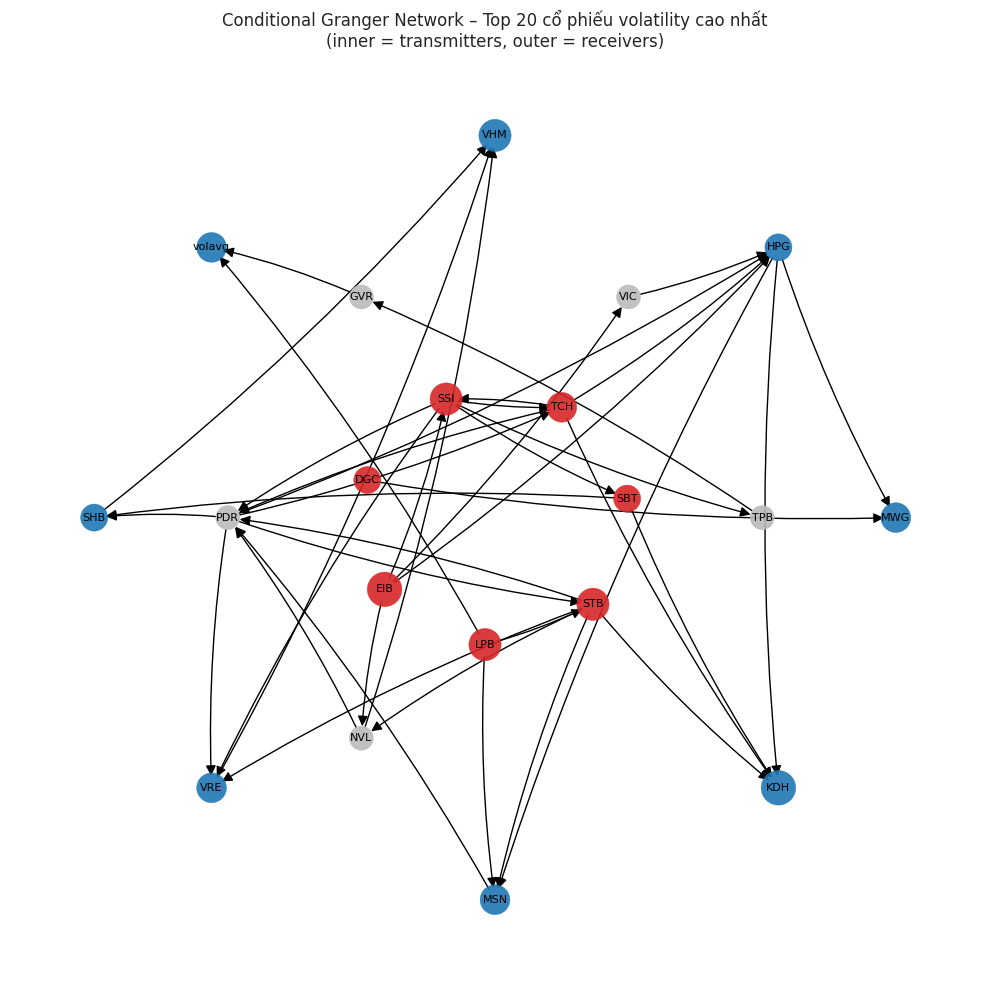

In [29]:
import networkx as nx
import matplotlib.pyplot as plt

G = nx.DiGraph()

# Thêm các cạnh theo adj_matrix
for i, cause in enumerate(stocks):
    for j, effect in enumerate(stocks):
        if adj_matrix.iloc[i, j] == 1:
            G.add_edge(cause, effect)

# Phân nhóm node
transmitters = deg_df[deg_df["net_degree"] > 0].index.tolist()
receivers    = deg_df[deg_df["net_degree"] < 0].index.tolist()
neutrals     = deg_df[deg_df["net_degree"] == 0].index.tolist()

print("Transmitters:", transmitters)
print("Receivers   :", receivers)
print("Neutrals    :", neutrals)

# Shell layout: inner=transmitters, middle=neutrals, outer=receivers
shells = []
if transmitters:
    shells.append(transmitters)
if neutrals:
    shells.append(neutrals)
if receivers:
    shells.append(receivers)

if shells:
    pos = nx.shell_layout(G, nlist=shells)
else:
    pos = nx.spring_layout(G, k=0.5, iterations=200)

# Màu node theo nhóm
colors = []
for n in G.nodes():
    if n in transmitters:
        colors.append("#d62728")   # đỏ
    elif n in receivers:
        colors.append("#1f77b4")   # xanh
    else:
        colors.append("#bbbbbb")   # xám

# Kích thước node theo độ lớn |net_degree|
node_sizes = []
for n in G.nodes():
    size = 300 + 80 * abs(deg_df.loc[n, "net_degree"])
    node_sizes.append(size)

plt.figure(figsize=(10, 10))
nx.draw_networkx_nodes(G, pos,
                       node_color=colors,
                       node_size=node_sizes,
                       alpha=0.9)
nx.draw_networkx_edges(G, pos,
                       arrows=True,
                       arrowstyle="-|>",
                       arrowsize=15,
                       width=1.0,
                       connectionstyle="arc3,rad=0.05")
nx.draw_networkx_labels(G, pos,
                        font_size=8)

plt.title("Conditional Granger Network – Top 20 cổ phiếu volatility cao nhất\n"
          "(inner = transmitters, outer = receivers)")
plt.axis("off")
plt.tight_layout()
plt.show()

Nodes: 20
Edges: 40
Transmitters: ['TCH', 'SSI', 'DGC', 'EIB', 'LPB', 'STB', 'SBT']
Receivers   : ['SHB', 'VRE', 'MSN', 'KDH', 'MWG', 'HPG', 'VHM', 'volavg']
Neutrals    : ['GVR', 'PDR', 'NVL', 'BCM', 'TPB', 'VIC']


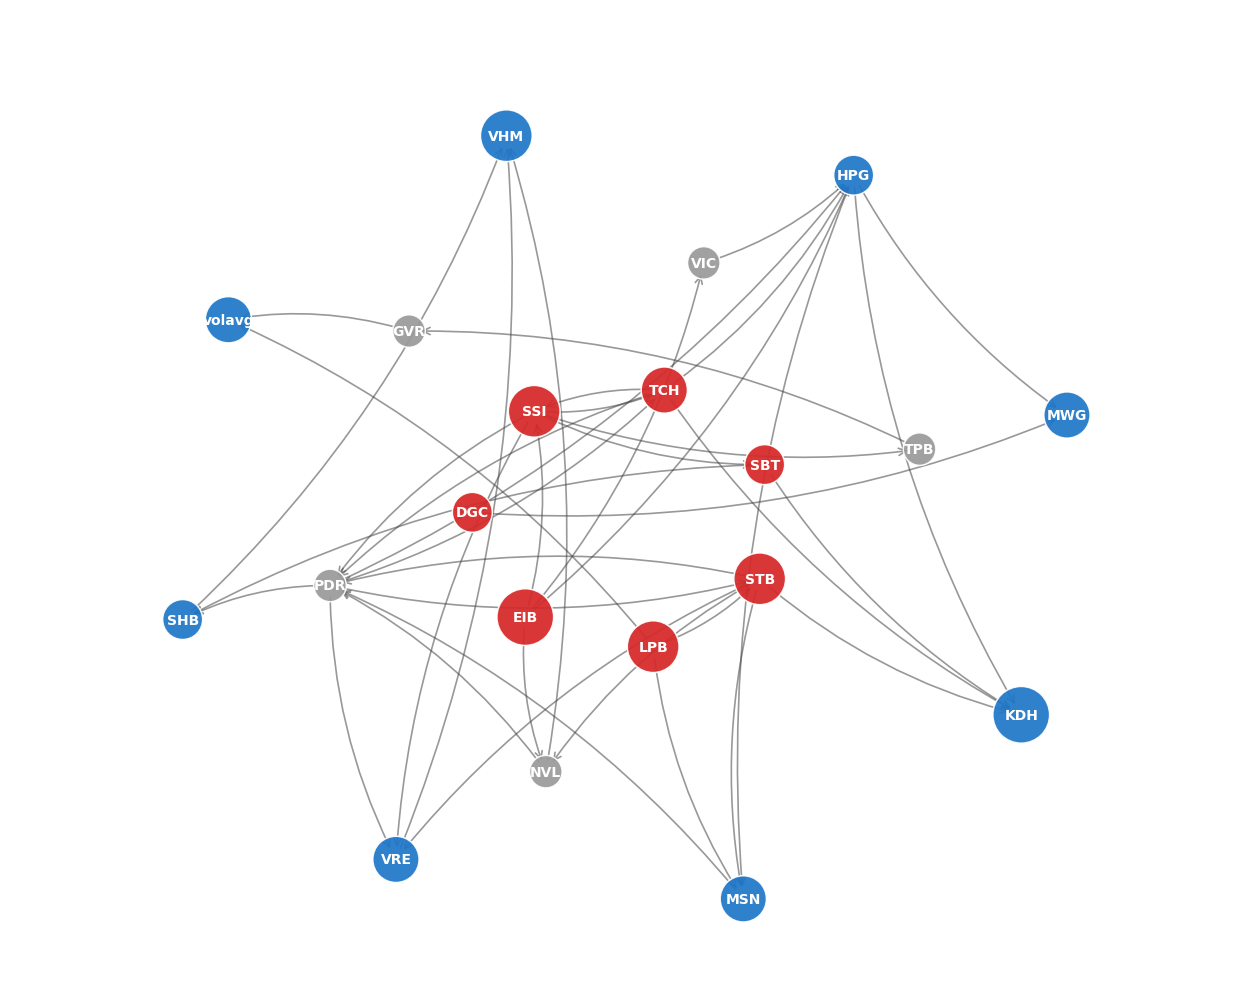

Đã lưu: network_volume.png & network_volume.svg


In [30]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np

G = nx.DiGraph()

# --- Add edges (cause -> effect from adj_matrix) ---
for i, cause in enumerate(stocks):
    for j, effect in enumerate(stocks):
        if adj_matrix.iloc[i, j] == 1:
            G.add_edge(cause, effect)

print("Nodes:", G.number_of_nodes())
print("Edges:", G.number_of_edges())

# --- Node roles ---
transmitters = deg_df[deg_df["net_degree"] > 0].index.tolist()
receivers    = deg_df[deg_df["net_degree"] < 0].index.tolist()
neutrals     = deg_df[deg_df["net_degree"] == 0].index.tolist()

print("Transmitters:", transmitters)
print("Receivers   :", receivers)
print("Neutrals    :", neutrals)

# --- Node size ---
node_sizes = [550 + 280 * abs(deg_df.loc[n, "net_degree"]) for n in G.nodes()]

# --- Node colors ---
node_colors = []
for n in G.nodes():
    if n in transmitters:
        node_colors.append("#d62828")
    elif n in receivers:
        node_colors.append("#2077c9")
    else:
        node_colors.append("#9a9a9a")

# --- Shell layout ---
shells = []
if len(transmitters) > 0: shells.append(transmitters)
if len(neutrals) > 0:     shells.append(neutrals)
if len(receivers) > 0:    shells.append(receivers)

pos = nx.shell_layout(G, nlist=shells)

# Rotate
angle = np.pi / 12
rot_pos = {
    k: (x*np.cos(angle) - y*np.sin(angle),
        x*np.sin(angle) + y*np.cos(angle))
    for k, (x, y) in pos.items()
}

plt.figure(figsize=(11, 10))
plt.style.use("seaborn-v0_8")

# --- Draw edges ---
nx.draw_networkx_edges(
    G, rot_pos,
    arrowstyle="->",
    arrowsize=13,
    width=1.2,
    alpha=0.55,
    edge_color="#444444",
    connectionstyle="arc3,rad=0.12"
)

# --- Draw nodes ---
nx.draw_networkx_nodes(
    G, rot_pos,
    node_size=node_sizes,
    node_color=node_colors,
    edgecolors="white",
    linewidths=1.1,
    alpha=0.93
)

# --- Draw labels ---
nx.draw_networkx_labels(
    G, rot_pos,
    font_size=10,
    font_weight="bold",
    font_color="white"
)

plt.title(
    "Conditional Granger Network – Top 20 Stocks by Volume"
    "(Inner = Transmitters, Outer = Receivers)",
    fontsize=16,
    fontweight="bold",
    color="white",
    pad=22
)

plt.axis("off")
plt.tight_layout()

# =========  SAVE ẢNH RÕ NÉT  =========
plt.savefig("network_volume.png", dpi=600, bbox_inches="tight")      # PNG HD
plt.savefig("network_volume.svg", format="svg", bbox_inches="tight") # SVG Vector
# =====================================

plt.show()

print("Đã lưu: network_volume.png & network_volume.svg")